# 9. Three-dimensional tidal heating

The Love numbers of notebook 8 collapse the whole response into a few surface numbers. But the tidal
strain, and therefore the heating, actually varies with position: with depth, with latitude, and with
longitude. TidalPy can build that full field from the same radial solution, driven by the world's tidal
potential.

This notebook builds a rheological Io, then reads its secular (orbit-averaged) volumetric heating as a
function of colatitude, maps it over the surface, and profiles it with depth. The pieces are the same as
before: a manually assembled layered world with an equation of state, a viscosity, and a rheology, plus
a rheology-based tide model.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.worlds.layered import LayeredWorld
from TidalPy.structures_x.layers.physics import PhysicsLayer
from TidalPy.Material_x.eos.material_eos import ConstantDensityEOS
from TidalPy.viscosity_x import make_viscosity
from TidalPy.rheology_x import Maxwell
from TidalPy.Tides_x.classes import make_tide

R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
M_JUP = 1.898e27
A_IO = 4.217e8
E_IO = 0.0041
N_MOTION = np.sqrt(G * M_JUP / A_IO**3)

io = LayeredWorld("Io", R, M)
mantle = PhysicsLayer("mantle", 0, 0.0, R, M, shear_modulus_static_pa=60.0e9, bulk_modulus_static_pa=200.0e9)
mantle.set_eos(ConstantDensityEOS(reference_density_kg_m3=RHO))
mantle.set_shear_viscosity(make_viscosity("constant", {"reference_viscosity": 1.0e15}))
mantle.set_bulk_viscosity(make_viscosity("constant", {"reference_viscosity": 1.0e30}))
mantle.set_shear_rheology(Maxwell())
mantle.set_bulk_rheology(Maxwell())
io.add_layer(mantle)

io.set_tide_model(make_tide("rheology"))
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)
io.solve_eos(G_to_use=G, temperature=1500.0, verbose=False)
io.set_spin_frequency(N_MOTION)

ORBIT = (N_MOTION, N_MOTION, E_IO, 0.0, A_IO, M_JUP)   # (n, spin, e, obliquity, a, host mass)
print("Io built and EOS solved:", io.eos_solved)


Io built and EOS solved: True


## Heating with latitude

`get_3d_tidal_heating` returns the secular volumetric heating (W/m^3) at a given radius and colatitude. Just below the surface, the eccentricity tide of a synchronous body deposits more heat near the poles than at the equator.

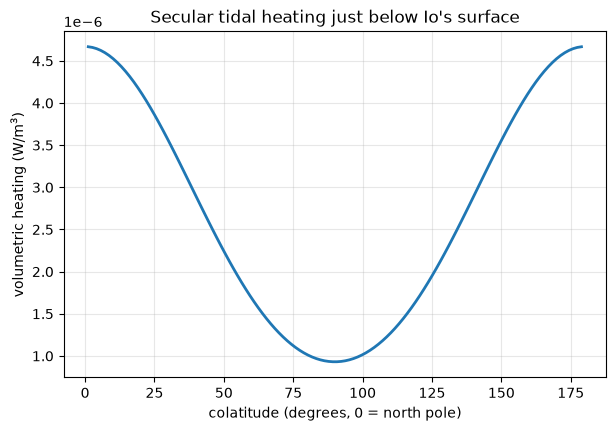

In [2]:
colats = np.linspace(0.02, np.pi - 0.02, 120)
h_surface = np.array([io.get_3d_tidal_heating(*ORBIT, 0.99 * R, c) for c in colats])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.degrees(colats), h_surface, lw=2)
ax.set_xlabel("colatitude (degrees, 0 = north pole)")
ax.set_ylabel("volumetric heating (W/m$^3$)")
ax.set_title("Secular tidal heating just below Io's surface")
ax.grid(alpha=0.3)
plt.show()


## A surface map

`calc_3d_tides` evaluates the field on a grid of radii, colatitudes, and longitudes and returns the `heating` array. Mapping it over the surface shows the characteristic pattern of an eccentricity tide, symmetric about the equator with maxima toward the poles.

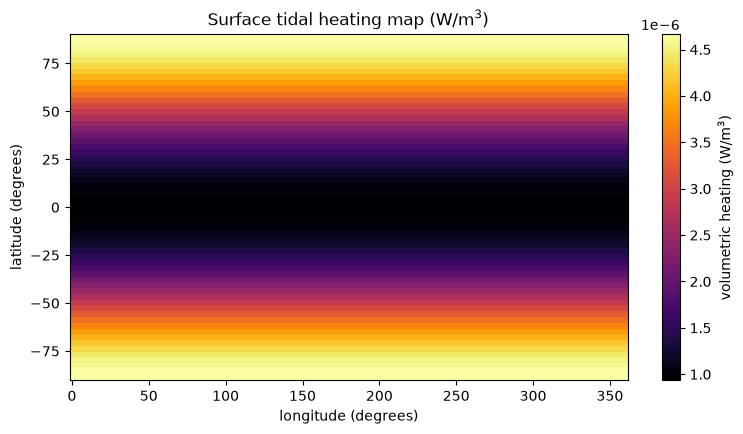

In [3]:
grid_colats = np.linspace(0.02, np.pi - 0.02, 60)
grid_lons = np.linspace(0.0, 2.0 * np.pi, 120)
result = io.calc_3d_tides(*ORBIT, radii=np.array([0.99 * R]),
                          colatitudes=grid_colats, longitudes=grid_lons)
heat_map = np.asarray(result["heating"])[0]      # (colatitude, longitude)

fig, ax = plt.subplots(figsize=(9, 4.5))
mesh = ax.pcolormesh(np.degrees(grid_lons), 90.0 - np.degrees(grid_colats), heat_map, cmap="inferno", shading="auto")
ax.set_xlabel("longitude (degrees)")
ax.set_ylabel("latitude (degrees)")
ax.set_title("Surface tidal heating map (W/m$^3$)")
fig.colorbar(mesh, ax=ax, label="volumetric heating (W/m$^3$)")
plt.show()


## Heating with depth

For a homogeneous body the strain, and thus the heating, grows outward, so the shells near the surface do most of the dissipating. Here is the polar profile from centre to surface.

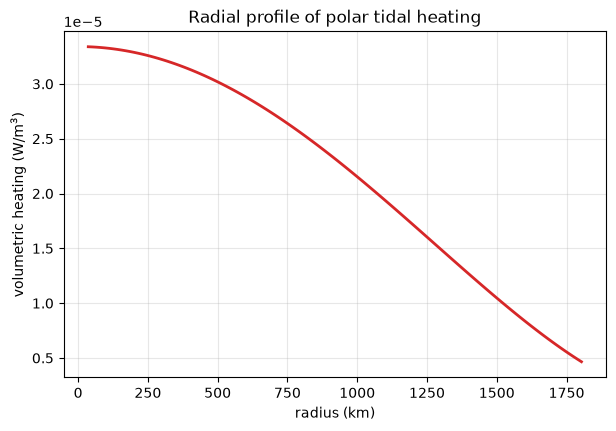

In [4]:
radii = np.linspace(0.02 * R, 0.99 * R, 120)
h_radial = np.array([io.get_3d_tidal_heating(*ORBIT, r, 0.05) for r in radii])   # near the north pole

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(radii / 1.0e3, h_radial, lw=2, color="tab:red")
ax.set_xlabel("radius (km)")
ax.set_ylabel("volumetric heating (W/m$^3$)")
ax.set_title("Radial profile of polar tidal heating")
ax.grid(alpha=0.3)
plt.show()


## Consistency with the total

Integrating the 3D field over the volume reproduces the single total heating from `calc_tides`, to within the resolution of the integration grid. The `calc_3d_tides` call can do that integral for us with its summed flavor.

In [5]:
io.calc_tides(*ORBIT)
total_1d = io.get_tidal_heating()

summed = io.calc_3d_tides(*ORBIT, latitude_summed=True, longitude_summed=True, radial_summed=True)
total_3d = float(np.asarray(summed["total"]))

print(f"total from calc_tides       : {total_1d:.4e} W")
print(f"volume integral of 3D field : {total_3d:.4e} W")


total from calc_tides       : 2.6489e+14 W
volume integral of 3D field : 2.5058e+14 W


## Recap

- The same radial solution that gives Love numbers also gives the full 3D tidal strain and heating.
- `get_3d_tidal_heating(..., radius, colatitude)` returns the secular volumetric heating at a point;
  `calc_3d_tides(..., radii=, colatitudes=, longitudes=)` returns it on a grid, or summed to a total.
- For a synchronous eccentric orbit the heating is polar-weighted and grows outward, and the volume
  integral matches the single total from `calc_tides`.

Next: **`10_thermal_eos`** looks at how the equation of state and temperature shape the interior.
